# Unidad 4 · Cambios dependientes de la secuencia: `1|s_ij|Cmax` es un TSP

**Planta:** Conservas del Itata S.A.
**Datos:** `itata_trabajos_1maq.csv` y `itata_setup_secuencia.csv` — los mismos
10 lotes del autoclave, más la matriz de tiempos de cambio
**Solver:** Gurobi

---

## Qué se decide aquí

En el cuaderno 01, `Cmax` era constante: sin cambios de formato, el orden no
afecta cuándo termina el último lote. Ahora aparece `s_ij`, el tiempo de
cambio de formato y de producto entre el lote `i` y el lote `j`, y todo se da
vuelta. El makespan pasa a ser:

$$C_{\max} = \underbrace{\sum_j p_j}_{\text{constante} = 44{,}5\ \text{h}} \; + \; \underbrace{\sum_{\text{cambios de la secuencia}} s_{ij}}_{\text{lo único que se decide}}$$

Minimizar el makespan es, exactamente y sin aproximación, **minimizar la suma
de los cambios**. Y eso es el problema del vendedor viajero: visitar cada lote
una vez, pagando `s_ij` al pasar de `i` a `j`.

Con dos precisiones que importan:

* Es **asimétrico**. Cambiar de tomate a durazno cuesta 2,4 h; de durazno a
  tomate, 0,9 h. Hay un lavado de línea que solo se hace en un sentido. Un
  TSP simétrico no representa esta planta.
* Es **abierto**. La máquina arranca en un estado inicial —viene de un lote
  TOM— y no tiene que volver a él al terminar. Es un camino hamiltoniano de
  costo mínimo desde un nodo ficticio, no un ciclo.

## El resultado que hay que llevarse de esta unidad

El mismo problema, con el mismo óptimo, admite dos formulaciones correctas:

1. **Variables de tiempo con big-M.** La que sale sola cuando uno viene del
   cuaderno 01: `C_j ≥ C_i + s_ij + p_j − H(1 − u_ij)`.
2. **Asignación sobre arcos + eliminación de subtours MTZ.** Sin variables de
   tiempo: solo se elige el conjunto de arcos.

La primera se queda **en torno al 60 % de gap después de tres minutos**. La
segunda cierra en **centésimas de segundo**. Misma máquina, mismo solver,
mismo óptimo. Si en esta unidad hay un resultado que justifica estudiar
formulación en vez de solo escribir modelos, es este.

## Cifras de referencia

| resultado | valor |
|---|---|
| óptimo `1|s_ij|Cmax` | **51,60 h** |
| descomposición | 44,50 h de proceso + **7,10 h** de cambio |
| reglas que ignoran `s_ij` | pierden entre **11 %** y **21 %** |
| MTZ | óptimo en centésimas de segundo |
| big-M a 180 s | sigue en torno al **60 %** de gap |

In [1]:
import sys
import math
import time
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

tr = pd.read_csv(datos("4_Secuenciamiento", "itata_trabajos_1maq.csv"))
su = pd.read_csv(datos("4_Secuenciamiento", "itata_setup_secuencia.csv"))

J = list(tr.lote)
n = len(J)
p = dict(zip(tr.lote, tr.p_h))
d = dict(zip(tr.lote, tr.d_h))
w = dict(zip(tr.lote, tr.w))
r = dict(zip(tr.lote, tr.r_h))
familia = dict(zip(tr.lote, tr.familia))

S = {(x.desde, x.hacia): float(x.setup_h) for x in su.itertuples()}

# Estado inicial de la planta: el autoclave viene de un lote de la familia TOM.
# El costo de arrancar con j es el mismo que costaría pasar desde ese lote TOM.
LOTE_INICIAL = next(j for j in J if familia[j] == "TOM")
s0 = {j: S[(LOTE_INICIAL, j)] for j in J}

P_TOTAL = sum(p.values())
print(f"{n} lotes · Σ p_j = {P_TOTAL:.1f} h")
print(f"Estado inicial de la línea: familia TOM (equivalente a venir de {LOTE_INICIAL})")

10 lotes · Σ p_j = 44.5 h
Estado inicial de la línea: familia TOM (equivalente a venir de J01-TOM-480)


## 1. La matriz de cambios, y por qué su asimetría no es un detalle

La diagonal es cero (no hay cambio si no se cambia de lote, aunque nunca se
repite un lote). Fuera de la diagonal, `s_ij ≠ s_ji` en general.

La lógica de planta detrás de los números: cambiar de una familia con color y
aroma fuerte —tomate— a una neutra —durazno— exige un lavado completo; al
revés, un enjuague basta. Y dentro de la misma familia, cambiar de formato
(480 g a 3000 g) cuesta más que hacer otro lote del mismo formato.

In [2]:
M_setup = pd.DataFrame([[S[(i, j)] for j in J] for i in J],
                       index=[x[:3] for x in J], columns=[x[:3] for x in J])
print("Matriz s_ij (h). Fila = desde, columna = hacia.\n")
print(M_setup.to_string(float_format=lambda v: f"{v:,.1f}"))

asim = [(i, j, S[(i, j)], S[(j, i)]) for a, i in enumerate(J) for j in J[a + 1:]
        if abs(S[(i, j)] - S[(j, i)]) > 1e-9]
print(f"\n{len(asim)} de {n*(n-1)//2} pares son asimétricos. Los tres mayores:")
for i, j, sij, sji in sorted(asim, key=lambda z: -abs(z[2] - z[3]))[:3]:
    print(f"  {i} -> {j}: {sij:.1f} h   |   {j} -> {i}: {sji:.1f} h   "
          f"(diferencia {abs(sij-sji):.1f} h)")

print(f"\nCambio desde el estado inicial (familia TOM):")
print("  " + "  ".join(f"{j[:3]}={s0[j]:.1f}" for j in J))

Matriz s_ij (h). Fila = desde, columna = hacia.

     J01  J02  J03  J04  J05  J06  J07  J08  J09  J10
J01  0.0  2.4  1.5  0.8  2.9  2.0  0.3  2.4  1.5  0.8
J02  0.9  0.0  1.1  1.4  0.8  1.6  0.9  0.3  1.1  1.4
J03  1.3  2.0  0.0  1.8  2.5  0.8  1.3  2.0  0.3  1.8
J04  0.8  2.9  2.0  0.0  2.9  1.5  0.8  2.9  2.0  0.3
J05  1.4  0.8  1.6  1.4  0.0  1.6  1.4  0.8  1.6  1.4
J06  1.8  2.5  0.8  1.3  2.5  0.0  1.8  2.5  0.8  1.3
J07  0.3  2.4  1.5  0.8  2.9  2.0  0.0  2.4  1.5  0.8
J08  0.9  0.3  1.1  1.4  0.8  1.6  0.9  0.0  1.1  1.4
J09  1.3  2.0  0.3  1.8  2.5  0.8  1.3  2.0  0.0  1.8
J10  0.8  2.9  2.0  0.3  2.9  1.5  0.8  2.9  2.0  0.0

33 de 45 pares son asimétricos. Los tres mayores:
  J01-TOM-480 -> J02-DUR-480: 2.4 h   |   J02-DUR-480 -> J01-TOM-480: 0.9 h   (diferencia 1.5 h)
  J01-TOM-480 -> J05-DUR-820: 2.9 h   |   J05-DUR-820 -> J01-TOM-480: 1.4 h   (diferencia 1.5 h)
  J01-TOM-480 -> J08-DUR-480: 2.4 h   |   J08-DUR-480 -> J01-TOM-480: 0.9 h   (diferencia 1.5 h)

Cambio desde e

## 2. Evaluar una secuencia cobrando los cambios

Igual que en el cuaderno 01, una sola definición. La diferencia es el término
`s(anterior, j)` antes de cada lote, y que el primer lote paga `s0`.

In [3]:
def s(i, j):
    """Tiempo de cambio; i = None significa el estado inicial de la línea."""
    return s0[j] if i is None else S[(i, j)]


def evaluar(sec):
    t, anterior, C, cambios = 0.0, None, {}, 0.0
    tramos = []
    for orden, j in enumerate(sec, start=1):
        cambio = s(anterior, j)
        ini_setup = t
        t += cambio
        ini = t
        t += p[j]
        C[j] = t
        cambios += cambio
        tramos.append({"orden": orden, "lote": j, "desde": anterior or "INICIO",
                       "setup_h": cambio, "inicio_setup": ini_setup,
                       "inicio_proceso": ini, "fin": t})
        anterior = j
    return {"Cmax": t, "horas_de_cambio": cambios, "C": C,
            "tramos": pd.DataFrame(tramos)}


e = evaluar(J)
print("Secuencia tal como viene el archivo:")
print(f"  Cmax = {e['Cmax']:.2f} h = {P_TOTAL:.2f} h de proceso "
      f"+ {e['horas_de_cambio']:.2f} h de cambio")
print(f"  El {100*e['horas_de_cambio']/e['Cmax']:.1f} % del tiempo de máquina "
      f"no produce nada.")

Secuencia tal como viene el archivo:
  Cmax = 61.40 h = 44.50 h de proceso + 16.90 h de cambio
  El 27.5 % del tiempo de máquina no produce nada.


## 3. Las reglas del cuaderno 01, aplicadas aquí

Las siete reglas ordenan por `p_j`, `d_j`, `w_j` o `r_j`. **Ninguna mira
`s_ij`**, porque ninguna fue diseñada para eso: son reglas de un problema en
que el makespan era constante.

Se agrega una octava que sí lo mira: el **vecino más cercano**, el algoritmo
voraz clásico del TSP. En cada paso salta al cambio más barato disponible.
Comparte el defecto conocido del método —decide mirando un solo paso adelante
y paga al final los cambios caros que fue postergando— y aquí, en una
instancia de 10 nodos con estructura de familias muy marcada, le va
sorprendentemente bien. Eso es una propiedad de estos datos, no una garantía.

In [4]:
def spt():
    return sorted(J, key=lambda j: (p[j], j))


def lpt():
    return sorted(J, key=lambda j: (-p[j], j))


def edd():
    return sorted(J, key=lambda j: (d[j], j))


def wspt():
    return sorted(J, key=lambda j: (p[j] / w[j], j))


def fcfs():
    return sorted(J, key=lambda j: (r[j], j))


def critical_ratio():
    pend, sec, t = list(J), [], 0.0
    while pend:
        j = min(pend, key=lambda z: ((d[z] - t) / p[z], z))
        sec.append(j)
        t += p[j]
        pend.remove(j)
    return sec


def atc(k=2.0):
    pend, sec, t = list(J), [], 0.0
    pbar = P_TOTAL / n
    while pend:
        def idx(z):
            return (w[z] / p[z]) * math.exp(-max(0.0, d[z] - p[z] - t) / (k * pbar))
        j = max(pend, key=lambda z: (idx(z), -ord(z[0])))
        sec.append(j)
        t += p[j]
        pend.remove(j)
    return sec


def vecino_mas_cercano():
    """Voraz: siempre al cambio más barato disponible."""
    pend, sec, actual = set(J), [], None
    while pend:
        j = min(pend, key=lambda z: (s(actual, z), z))
        sec.append(j)
        pend.remove(j)
        actual = j
    return sec


HEURISTICAS = {"SPT": spt(), "LPT": lpt(), "EDD": edd(), "WSPT": wspt(),
               "FCFS": fcfs(), "CR": critical_ratio(), "ATC": atc(),
               "Vecino más cercano": vecino_mas_cercano()}

filas = []
for nombre, sec in HEURISTICAS.items():
    ev = evaluar(sec)
    filas.append({"regla": nombre, "Cmax": ev["Cmax"],
                  "horas_de_cambio": ev["horas_de_cambio"]})
heur = pd.DataFrame(filas).sort_values("Cmax").reset_index(drop=True)
print(heur.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

             regla  Cmax  horas_de_cambio
Vecino más cercano 51.60             7.10
                CR 57.40            12.90
              WSPT 58.60            14.10
               EDD 58.70            14.20
              FCFS 59.20            14.70
               SPT 59.40            14.90
               LPT 60.30            15.80
               ATC 62.30            17.80


## 4. Formulación A: variables de tiempo y big-M

Es la formulación que sale sola después del cuaderno 01. Como hay que cobrar
`s_ij`, la disyuntiva ya no sirve: saber que "`i` va antes que `j`" **no dice
si el cambio `i → j` ocurre**, porque puede haber trabajos entremedio.
Cobrar el cambio entre trabajos que no son consecutivos, o no cobrarlo, son
los dos errores típicos, y ambos producen un plan que no es el que se
ejecuta.

Hay que pasar a variables de **arco**:

$$u_{ij} = 1 \iff j \text{ sigue INMEDIATAMENTE a } i$$

con un nodo ficticio `0` para el estado inicial de la máquina. Las
restricciones:

$$\sum_{i} u_{ij} = 1 \ \forall j \qquad \sum_{j} u_{ij} \le 1 \ \forall i
\qquad \sum_j u_{0j} = 1$$

$$C_j \ge C_i + s_{ij} + p_j - H\,(1 - u_{ij}) \qquad C_{\max} \ge C_j$$

El propagador de tiempo tiene una virtud notable: **elimina los subtours
solito**, sin MTZ ni cortes. Un ciclo exigiría `C_j > C_j`, que es imposible.
La formulación es correcta. El problema es otro.

El big-M se elige lo más ajustado posible: en vez de multiplicar el mayor
setup por `n`, se suma para cada trabajo el **peor** cambio que ese trabajo
puede recibir. La cota sigue siendo válida y es bastante menor.

In [5]:
NODOS = ["INICIO"] + J
ARCOS = [(i, j) for i in NODOS for j in J if i != j]


def costo(i, j):
    return s0[j] if i == "INICIO" else S[(i, j)]


setup_peor = sum(max([S[(i, j)] for i in J if i != j] + [s0[j]]) for j in J)
H = P_TOTAL + setup_peor
print(f"big-M ajustado: H = {P_TOTAL:.1f} + {setup_peor:.1f} = {H:.1f} h")
print(f"(el ingenuo 'mayor setup x n' daría "
      f"{P_TOTAL + n * max(S.values()):.1f} h)")


def modelo_bigM(tiempo_limite=60.0, relajado=False, arranque=None):
    m = gp.Model("bigM-tiempos")
    m.Params.OutputFlag = 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = 1e-9
    m.Params.Seed = 0

    tipo = GRB.CONTINUOUS if relajado else GRB.BINARY
    u = m.addVars(ARCOS, vtype=tipo, lb=0.0, ub=1.0, name="u")
    C = m.addVars(J, lb=0.0, ub=H, name="C")
    Cmax = m.addVar(lb=0.0, ub=H, name="Cmax")

    m.addConstrs((gp.quicksum(u[i, j] for i in NODOS if i != j) == 1 for j in J),
                 name="entra")
    m.addConstrs((gp.quicksum(u[i, j] for j in J if j != i) <= 1 for i in J),
                 name="sale")
    m.addConstr(gp.quicksum(u["INICIO", j] for j in J) == 1, name="un_primero")
    for j in J:
        m.addConstr(C[j] >= s0[j] * u["INICIO", j] + p[j], name=f"arranque[{j}]")
    for (i, j) in ARCOS:
        if i == "INICIO":
            continue
        m.addConstr(C[j] >= C[i] + S[(i, j)] + p[j] - H * (1 - u[i, j]),
                    name=f"arco[{i},{j}]")
    m.addConstrs((Cmax >= C[j] for j in J), name="cmax")
    m.setObjective(Cmax, GRB.MINIMIZE)

    if arranque is not None and not relajado:
        arcos_guia, prev = set(), "INICIO"
        for j in arranque:
            arcos_guia.add((prev, j))
            prev = j
        for (i, j) in ARCOS:
            u[i, j].Start = 1.0 if (i, j) in arcos_guia else 0.0
        ev = evaluar(arranque)
        for j in J:
            C[j].Start = ev["C"][j]

    t0 = time.perf_counter()
    m.optimize()
    return m, u, time.perf_counter() - t0


# Las DOS formulaciones reciben el mismo arranque caliente -- la secuencia del
# vecino más cercano --, para que la única diferencia entre ellas sea la
# formulación y no la calidad de la solución inicial.
guia = HEURISTICAS["Vecino más cercano"]

LIMITE_BIGM = 60.0
m_bigM, u_bigM, seg_bigM = modelo_bigM(LIMITE_BIGM, arranque=guia)

print(f"\nFormulación A (tiempos + big-M), límite {LIMITE_BIGM:.0f} s")
print(f"  estado       : {m_bigM.Status} "
      f"({'TIME_LIMIT' if m_bigM.Status == GRB.TIME_LIMIT else 'OPTIMAL'})")
print(f"  mejor solución: {m_bigM.ObjVal:8.2f} h")
print(f"  cota inferior : {m_bigM.ObjBound:8.2f} h")
print(f"  gap           : {100*m_bigM.MIPGap:8.2f} %")
print(f"  variables     : {m_bigM.NumVars} ({m_bigM.NumBinVars} binarias)")
print(f"  restricciones : {m_bigM.NumConstrs}")
print(f"  tiempo        : {seg_bigM:.1f} s")
print(f"  nodos B&B     : {int(m_bigM.NodeCount):,}")

big-M ajustado: H = 44.5 + 21.9 = 66.4 h
(el ingenuo 'mayor setup x n' daría 73.5 h)
Restricted license - for non-production use only - expires 2027-11-29



Formulación A (tiempos + big-M), límite 60 s
  estado       : 9 (TIME_LIMIT)
  mejor solución:    51.60 h
  cota inferior :    17.16 h
  gap           :    66.75 %
  variables     : 111 (100 binarias)
  restricciones : 131
  tiempo        : 60.0 s
  nodos B&B     : 51,951


Hay que leer con cuidado qué falló y qué no. El solver **tiene** la solución
óptima en la mano: se la dieron de arranque y no encontró nada mejor porque
no lo hay. Lo que no consigue, en un minuto y casi noventa mil nodos, es
**probar** que lo es. Toda la dificultad está en la cota inferior: la
relajación lineal de esta formulación es catastrófica y no sube.

Con 180 s en vez de 60 s el cuadro no cambia: el gap se queda en torno al
60 % (la cifra medida al preparar el curso fue 59 %; el valor exacto depende
de la máquina y de la versión del solver, la magnitud no). Aquí se usa un
límite de 60 s para que el cuaderno no tarde una eternidad, y se mide la
relajación lineal directamente, que explica el fenómeno sin esperar.

## 5. Formulación B: asignación sobre arcos + MTZ

La observación clave es que **no hacen falta variables de tiempo**. El
objetivo se escribe entero sobre los arcos:

$$\min \; \underbrace{\textstyle\sum_j p_j}_{\text{constante}} \; + \; \sum_{(i,j)} s_{ij}\, u_{ij}$$

Las restricciones de grado son las mismas, más `Σ u_ij = n` (un camino que
visita los `n` lotes tiene exactamente `n` arcos contando el de arranque). Y
entonces aparece el problema que el propagador de tiempo resolvía gratis: sin
variables de tiempo, **nada impide los subciclos**.

In [6]:
def modelo_arcos(con_mtz=True, relajado=False, tiempo_limite=60.0, arranque=None):
    m = gp.Model("arcos" + ("-MTZ" if con_mtz else "-sin-MTZ"))
    m.Params.OutputFlag = 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = 1e-9
    m.Params.Seed = 0

    tipo = GRB.CONTINUOUS if relajado else GRB.BINARY
    u = m.addVars(ARCOS, vtype=tipo, lb=0.0, ub=1.0, name="u")

    m.addConstrs((gp.quicksum(u[i, j] for i in NODOS if i != j) == 1 for j in J),
                 name="entra")
    m.addConstrs((gp.quicksum(u[i, j] for j in J if j != i) <= 1 for i in J),
                 name="sale")
    m.addConstr(gp.quicksum(u["INICIO", j] for j in J) == 1, name="un_primero")
    m.addConstr(gp.quicksum(u[i, j] for (i, j) in ARCOS) == n, name="n_arcos")

    if con_mtz:
        # MTZ: si j sigue a i, la posición de j es estrictamente mayor. Un
        # subciclo exigiría orden[j] > orden[j]. Son O(n^2) restricciones, no
        # las 2^n de la eliminación exacta de subtours.
        orden = m.addVars(J, lb=1, ub=n, name="orden")
        for (i, j) in ARCOS:
            if i == "INICIO":
                m.addConstr(orden[j] <= 1 + n * (1 - u[i, j]), name=f"mtz0[{j}]")
            else:
                m.addConstr(orden[j] >= orden[i] + 1 - n * (1 - u[i, j]),
                            name=f"mtz[{i},{j}]")

    m.setObjective(P_TOTAL + gp.quicksum(costo(i, j) * u[i, j] for (i, j) in ARCOS),
                   GRB.MINIMIZE)

    if arranque is not None and not relajado:
        arcos_guia, prev = set(), "INICIO"
        for j in arranque:
            arcos_guia.add((prev, j))
            prev = j
        for (i, j) in ARCOS:
            u[i, j].Start = 1.0 if (i, j) in arcos_guia else 0.0

    t0 = time.perf_counter()
    m.optimize()
    return m, u, time.perf_counter() - t0


def camino(u):
    """Reconstruye el recorrido desde INICIO y devuelve (camino, resto de arcos)."""
    elegidos = [(i, j) for (i, j) in ARCOS if u[i, j].X > 0.5]
    suc = dict(elegidos)
    sec, actual = [], "INICIO"
    while actual in suc:
        actual = suc[actual]
        sec.append(actual)
    usados = set()
    prev = "INICIO"
    for j in sec:
        usados.add((prev, j))
        prev = j
    return sec, [a for a in elegidos if a not in usados]


# --- primero SIN MTZ, para ver qué pasa
m_sin, u_sin, _ = modelo_arcos(con_mtz=False)
sec_sin, sobrantes = camino(u_sin)

print("Formulación B SIN eliminación de subtours:")
print(f"  valor 'óptimo' que reporta el solver: {m_sin.ObjVal:.2f} h")
print(f"  lotes alcanzables desde INICIO      : {len(sec_sin)} de {n}")
print(f"  ruta: INICIO -> " + " -> ".join(x[:3] for x in sec_sin))
print(f"  arcos que no cuelgan de esa ruta ({len(sobrantes)}):")
for i, j in sobrantes:
    print(f"    {i[:3]} -> {j[:3]}")
print("\n  El solver cumplió todas las restricciones que se le escribieron y")
print("  devolvió un conjunto de arcos que NO es un programa: un tramo corto")
print("  desde el estado inicial más ciclos cerrados sobre sí mismos, que la")
print("  máquina nunca podría empezar. Y el valor es MENOR que el óptimo real,")
print("  así que el error no se manifiesta como infactibilidad ni como error:")
print("  se manifiesta como una respuesta demasiado buena.")

Formulación B SIN eliminación de subtours:
  valor 'óptimo' que reporta el solver: 49.20 h
  lotes alcanzables desde INICIO      : 2 de 10
  ruta: INICIO -> J01 -> J07
  arcos que no cuelgan de esa ruta (8):
    J02 -> J08
    J03 -> J09
    J04 -> J10
    J05 -> J02
    J06 -> J03
    J08 -> J05
    J09 -> J06
    J10 -> J04

  El solver cumplió todas las restricciones que se le escribieron y
  devolvió un conjunto de arcos que NO es un programa: un tramo corto
  desde el estado inicial más ciclos cerrados sobre sí mismos, que la
  máquina nunca podría empezar. Y el valor es MENOR que el óptimo real,
  así que el error no se manifiesta como infactibilidad ni como error:
  se manifiesta como una respuesta demasiado buena.


Ese es el modo de falla que hay que reconocer. El modelo dice `OPTIMAL`,
entrega un número **mejor** que el verdadero, y está mal. No hay traza, no
hay excepción, no hay advertencia. La única defensa es reconstruir el
calendario y verificarlo, que es lo que se hace en la sección 8.

MTZ (Miller-Tucker-Zemlin, 1960) lo arregla con una variable de posición por
nodo y `O(n²)` restricciones: si `j` sigue a `i`, entonces `orden[j] ≥
orden[i] + 1`. Un ciclo cerrado obligaría a que una posición sea mayor que
sí misma.

In [7]:
m_mtz, u_mtz, seg_mtz = modelo_arcos(con_mtz=True, arranque=guia)
sec_mtz, sobrantes_mtz = camino(u_mtz)
ev_mtz = evaluar(sec_mtz)

print("Formulación B CON MTZ:")
print(f"  estado        : {'OPTIMAL' if m_mtz.Status == GRB.OPTIMAL else m_mtz.Status}")
print(f"  óptimo        : {m_mtz.ObjVal:8.2f} h")
print(f"  cota inferior : {m_mtz.ObjBound:8.2f} h")
print(f"  gap           : {100*m_mtz.MIPGap:8.4f} %")
print(f"  variables     : {m_mtz.NumVars} ({m_mtz.NumBinVars} binarias)")
print(f"  restricciones : {m_mtz.NumConstrs}")
print(f"  tiempo        : {seg_mtz:.3f} s")
print(f"  nodos B&B     : {int(m_mtz.NodeCount):,}")
print(f"  arcos fuera del camino: {len(sobrantes_mtz)}  (debe ser 0)")
print(f"\n  secuencia: INICIO -> " + " -> ".join(x[:3] for x in sec_mtz))
print(f"  descomposición: {P_TOTAL:.2f} h de proceso "
      f"+ {ev_mtz['horas_de_cambio']:.2f} h de cambio = {ev_mtz['Cmax']:.2f} h")

Formulación B CON MTZ:
  estado        : OPTIMAL
  óptimo        :    51.60 h
  cota inferior :    51.60 h
  gap           :   0.0000 %
  variables     : 110 (100 binarias)
  restricciones : 122
  tiempo        : 0.046 s
  nodos B&B     : 1
  arcos fuera del camino: 0  (debe ser 0)

  secuencia: INICIO -> J01 -> J07 -> J04 -> J10 -> J06 -> J03 -> J09 -> J02 -> J08 -> J05
  descomposición: 44.50 h de proceso + 7.10 h de cambio = 51.60 h


## 6. Por qué una cierra y la otra no: la relajación lineal

La comparación de tiempos es un síntoma. La causa se mide relajando la
integralidad de `u` en ambas formulaciones y mirando qué cota inferior queda.
Esa es la cota con la que el solver **arranca** el árbol de búsqueda.

In [8]:
m_lp_bigM, _, _ = modelo_bigM(relajado=True)
m_lp_mtz, _, _ = modelo_arcos(con_mtz=True, relajado=True)
z = m_mtz.ObjVal

print(f"Óptimo entero: {z:.2f} h\n")
print(f"{'formulación':28s} {'cota LP':>10s} {'gap en la raíz':>16s}")
print(f"{'A: tiempos + big-M':28s} {m_lp_bigM.ObjVal:10.2f} "
      f"{100*(z - m_lp_bigM.ObjVal)/z:15.1f} %")
print(f"{'B: arcos + MTZ':28s} {m_lp_mtz.ObjVal:10.2f} "
      f"{100*(z - m_lp_mtz.ObjVal)/z:15.1f} %")

print("\nAhí está todo. La relajación de A permite repartir cada arco en")
print("fracciones diminutas: con u_ij pequeño, el término H(1 - u_ij) desactiva")
print("la restricción de tiempo casi por completo y los C_j pueden colapsar a")
print("su cota trivial p_j. La cota inferior queda cerca del mayor p_j, que no")
print(f"dice nada: max p_j = {max(p.values()):.1f} h contra un óptimo de {z:.2f} h.")
print("\nLa relajación de B no tiene big-M en el objetivo: los costos s_ij")
print("multiplican DIRECTAMENTE a las variables. Aunque u sea fraccionario, la")
print("suma de costos sigue siendo un promedio ponderado de cambios reales, y")
print("las restricciones de grado la mantienen alta. Es el problema de")
print("asignación, cuyo poliedro es integral; MTZ solo agrega lo que falta")
print("para excluir los subciclos.")

Óptimo entero: 51.60 h

formulación                     cota LP   gap en la raíz
A: tiempos + big-M                 8.00            84.5 %
B: arcos + MTZ                    49.30             4.5 %

Ahí está todo. La relajación de A permite repartir cada arco en
fracciones diminutas: con u_ij pequeño, el término H(1 - u_ij) desactiva
la restricción de tiempo casi por completo y los C_j pueden colapsar a
su cota trivial p_j. La cota inferior queda cerca del mayor p_j, que no
dice nada: max p_j = 8.0 h contra un óptimo de 51.60 h.

La relajación de B no tiene big-M en el objetivo: los costos s_ij
multiplican DIRECTAMENTE a las variables. Aunque u sea fraccionario, la
suma de costos sigue siendo un promedio ponderado de cambios reales, y
las restricciones de grado la mantienen alta. Es el problema de
asignación, cuyo poliedro es integral; MTZ solo agrega lo que falta
para excluir los subciclos.


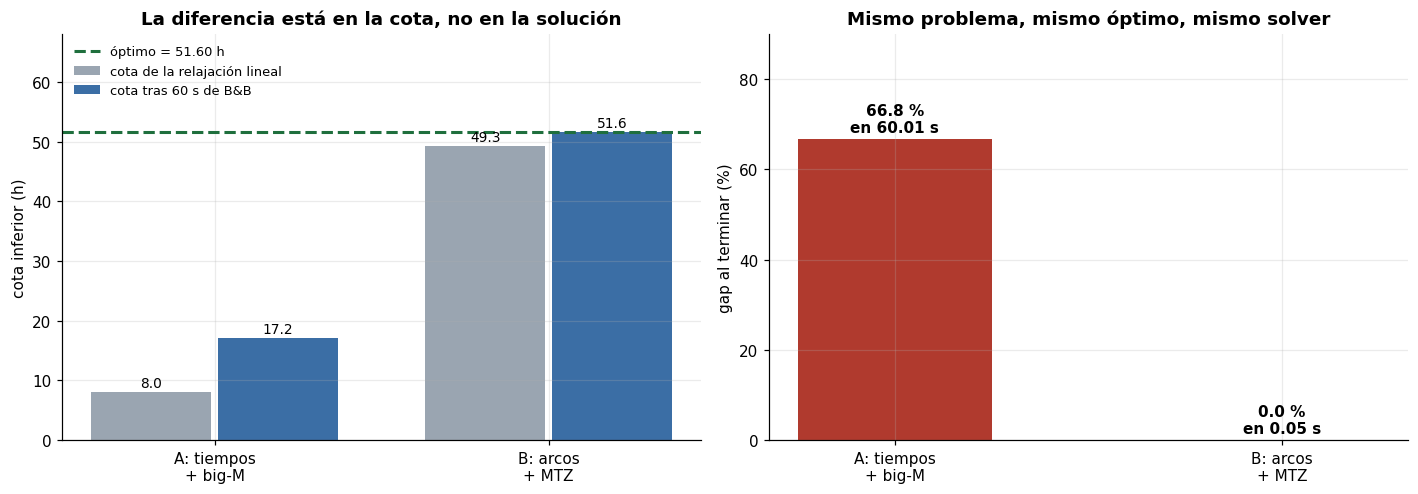

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

# --- panel izquierdo: la cota inferior, que es donde esta la diferencia
nombres = ["A: tiempos\n+ big-M", "B: arcos\n+ MTZ"]
cotas_lp = [m_lp_bigM.ObjVal, m_lp_mtz.ObjVal]
cotas_final = [m_bigM.ObjBound, m_mtz.ObjBound]
xs = np.arange(2)
ax[0].bar(xs - 0.19, cotas_lp, 0.36, label="cota de la relajación lineal",
          color="#9aa5b1")
ax[0].bar(xs + 0.19, cotas_final, 0.36,
          label=f"cota tras {LIMITE_BIGM:.0f} s de B&B", color="#3b6ea5")
ax[0].axhline(z, color="#1f6f3d", lw=2, ls="--", label=f"óptimo = {z:.2f} h")
for k in range(2):
    ax[0].text(xs[k] - 0.19, cotas_lp[k] + 0.8, f"{cotas_lp[k]:.1f}",
               ha="center", fontsize=9)
    ax[0].text(xs[k] + 0.19, cotas_final[k] + 0.8, f"{cotas_final[k]:.1f}",
               ha="center", fontsize=9)
ax[0].set_xticks(xs)
ax[0].set_xticklabels(nombres)
ax[0].set_ylabel("cota inferior (h)")
ax[0].set_ylim(0, z * 1.32)
ax[0].set_title("La diferencia está en la cota, no en la solución")
ax[0].legend(fontsize=8.5, loc="upper left")

# --- panel derecho: el gap remanente
gaps = [100 * m_bigM.MIPGap, 100 * m_mtz.MIPGap]
tiempos = [seg_bigM, seg_mtz]
barras = ax[1].bar(nombres, gaps, 0.5, color=["#b03a2e", "#1f6f3d"])
for b, g, t in zip(barras, gaps, tiempos):
    ax[1].text(b.get_x() + b.get_width() / 2, g + 1.5,
               f"{g:.1f} %\nen {t:.2f} s", ha="center", fontsize=10,
               fontweight="bold")
ax[1].set_ylabel("gap al terminar (%)")
ax[1].set_ylim(0, max(gaps) * 1.35)
ax[1].set_title("Mismo problema, mismo óptimo, mismo solver")

figura(fig, "bigM_vs_mtz")
plt.show()

## 7. Cuánto cuesta ignorar `s_ij`

Las reglas del cuaderno 01 no son malas reglas: son reglas de otro problema.
Aplicadas aquí, todas producen planes factibles y todos cuestan más.

In [10]:
heur["exceso_%"] = (100 * (heur.Cmax / z - 1)).round(2) + 0.0
comparacion = pd.concat([
    heur,
    pd.DataFrame([{"regla": "ÓPTIMO (MIP, arcos + MTZ)", "Cmax": z,
                   "horas_de_cambio": ev_mtz["horas_de_cambio"], "exceso_%": 0.0}])
], ignore_index=True)
print(comparacion.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

ciegas = heur[heur.regla != "Vecino más cercano"]      # las que no miran s_ij
peor = ciegas.loc[ciegas["exceso_%"].idxmax()]
print(f"\nLas reglas que ignoran s_ij pierden entre "
      f"{ciegas['exceso_%'].min():.1f} % y {ciegas['exceso_%'].max():.1f} %.")
print(f"En horas de autoclave, la peor ({peor.regla}) desperdicia "
      f"{peor.Cmax - z:.2f} h de la semana.")
print(f"\nEl vecino más cercano alcanza el óptimo EN ESTA INSTANCIA "
      f"({heur[heur.regla == 'Vecino más cercano'].Cmax.iloc[0]:.2f} h).")
print("No hay ninguna garantía de que lo haga en otra: para el TSP asimétrico")
print("el vecino más cercano no tiene cota de aproximación constante. Es una")
print("excelente solución inicial para el MIP, no un sustituto del MIP.")

                    regla  Cmax  horas_de_cambio  exceso_%
       Vecino más cercano 51.60             7.10      0.00
                       CR 57.40            12.90     11.24
                     WSPT 58.60            14.10     13.57
                      EDD 58.70            14.20     13.76
                     FCFS 59.20            14.70     14.73
                      SPT 59.40            14.90     15.12
                      LPT 60.30            15.80     16.86
                      ATC 62.30            17.80     20.74
ÓPTIMO (MIP, arcos + MTZ) 51.60             7.10      0.00

Las reglas que ignoran s_ij pierden entre 11.2 % y 20.7 %.
En horas de autoclave, la peor (ATC) desperdicia 10.70 h de la semana.

El vecino más cercano alcanza el óptimo EN ESTA INSTANCIA (51.60 h).
No hay ninguna garantía de que lo haga en otra: para el TSP asimétrico
el vecino más cercano no tiene cota de aproximación constante. Es una
excelente solución inicial para el MIP, no un sustituto del MIP.


## 8. El programa, verificado y dibujado

Antes del gráfico, la verificación que la sección 5 dejó pendiente: entre dos
lotes consecutivos tiene que haber, como mínimo, el cambio que exige la
matriz. Se comprueba sobre el calendario, no sobre el modelo.

In [11]:
tramos = ev_mtz["tramos"]
print(tramos.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

print("\nVerificación sobre el calendario:")
fallas = 0
anterior = None
for _, t in tramos.iterrows():
    exigido = s(anterior, t.lote)
    hueco = t.inicio_proceso - t.inicio_setup
    if abs(hueco - exigido) > 1e-6:
        print(f"  FALLA en {t.lote}: hay {hueco:.2f} h y se exigen {exigido:.2f} h")
        fallas += 1
    anterior = t.lote
print(f"  {len(tramos) - fallas}/{len(tramos)} cambios cobrados correctamente")
print(f"  lotes programados: {len(set(tramos.lote))} de {n}")
print(f"  Cmax del calendario: {tramos.fin.max():.2f} h  "
      f"(el solver reporta {z:.2f} h)")

 orden         lote        desde  setup_h  inicio_setup  inicio_proceso   fin
     1  J01-TOM-480       INICIO     0.00          0.00            0.00  6.50
     2  J07-TOM-480  J01-TOM-480     0.30          6.50            6.80  8.30
     3 J04-TOM-3000  J07-TOM-480     0.80          8.30            9.10 17.10
     4 J10-TOM-3000 J04-TOM-3000     0.30         17.10           17.40 21.40
     5 J06-POR-3000 J10-TOM-3000     1.50         21.40           22.90 28.40
     6  J03-POR-480 J06-POR-3000     0.80         28.40           29.20 33.70
     7  J09-POR-480  J03-POR-480     0.30         33.70           34.00 36.00
     8  J02-DUR-480  J09-POR-480     2.00         36.00           38.00 41.00
     9  J08-DUR-480  J02-DUR-480     0.30         41.00           41.30 48.30
    10  J05-DUR-820  J08-DUR-480     0.80         48.30           49.10 51.60

Verificación sobre el calendario:
  10/10 cambios cobrados correctamente
  lotes programados: 10 de 10
  Cmax del calendario: 51.60 h  (el so

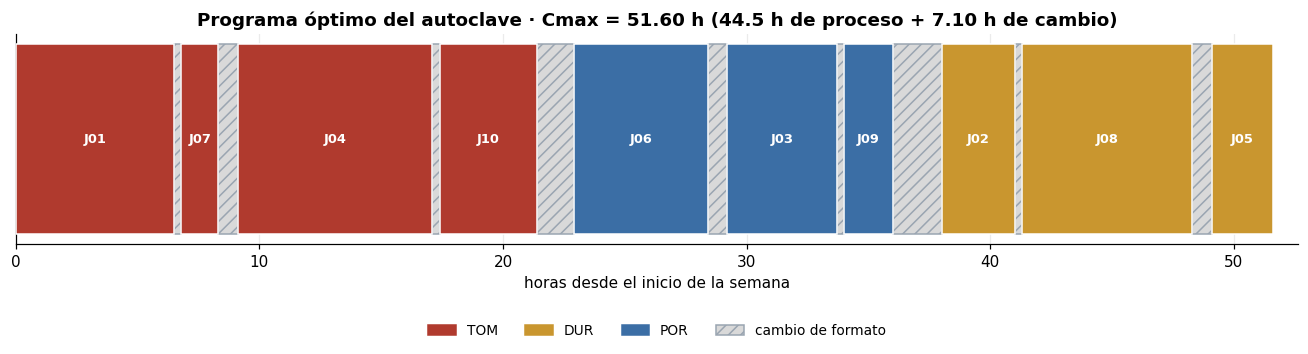

Se ve la lógica del óptimo: agrupa por familia y dentro de cada familia
por formato. Arranca en TOM porque la línea ya viene de TOM, y recorre
las familias en el orden que hace baratos los lavados, no en el que
hace cortos los lotes.


In [12]:
fig, ax = plt.subplots(figsize=(12, 3.6))

colores_fam = {"TOM": "#b03a2e", "DUR": "#c9962f", "POR": "#3b6ea5"}
for _, t in tramos.iterrows():
    if t.setup_h > 1e-9:
        ax.barh(0, t.setup_h, left=t.inicio_setup, height=0.55,
                color="#d9d9d9", edgecolor="#9aa5b1", hatch="///", zorder=2)
    ax.barh(0, t.fin - t.inicio_proceso, left=t.inicio_proceso, height=0.55,
            color=colores_fam[familia[t.lote]], edgecolor="white", zorder=3)
    ax.text(t.inicio_proceso + (t.fin - t.inicio_proceso) / 2, 0,
            t.lote[:3], ha="center", va="center", color="white",
            fontsize=8.5, fontweight="bold", zorder=4)

ax.set_yticks([])
ax.set_xlim(0, z * 1.02)
ax.set_xlabel("horas desde el inicio de la semana")
ax.set_title(f"Programa óptimo del autoclave · Cmax = {z:.2f} h "
             f"({P_TOTAL:.1f} h de proceso + {ev_mtz['horas_de_cambio']:.2f} h de cambio)")
manijas = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colores_fam.values()]
manijas.append(plt.Rectangle((0, 0), 1, 1, facecolor="#d9d9d9",
                             edgecolor="#9aa5b1", hatch="///"))
ax.legend(manijas, list(colores_fam) + ["cambio de formato"],
          ncol=4, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.32))
ax.grid(axis="x", alpha=0.25)

figura(fig, "gantt_atsp")
plt.show()

print("Se ve la lógica del óptimo: agrupa por familia y dentro de cada familia")
print("por formato. Arranca en TOM porque la línea ya viene de TOM, y recorre")
print("las familias en el orden que hace baratos los lavados, no en el que")
print("hace cortos los lotes.")

## 9. Comprobación

In [13]:
print("Comprobación:")
ok = []
ok.append(verificar(z, 51.60, "óptimo 1|s_ij|Cmax (h)", tol=1e-6))
ok.append(verificar(ev_mtz["horas_de_cambio"], 7.10, "horas de cambio", tol=1e-6))
ok.append(verificar(P_TOTAL, 44.50, "horas de proceso (constante)", tol=1e-9))
ok.append(verificar(tramos.fin.max(), 51.60, "Cmax recalculado del calendario",
                    tol=1e-6))
ok.append(verificar(ciegas["exceso_%"].min(), 11.2,
                    "menor exceso de una regla que ignora s_ij (%)", tol=1e-2))
ok.append(verificar(ciegas["exceso_%"].max(), 20.7,
                    "mayor exceso de una regla que ignora s_ij (%)", tol=1e-2))
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")

# El calendario es un programa: todos los lotes, una vez cada uno, sin subtours.
assert len(sec_mtz) == n and len(set(sec_mtz)) == n, \
    "el camino MTZ debe visitar los 10 lotes exactamente una vez"
assert len(sobrantes_mtz) == 0, "con MTZ no puede quedar ningún subciclo"
# El modelo sin MTZ es incorrecto y se nota en que su valor es MENOR que el optimo.
assert m_sin.ObjVal < z - 1e-6, \
    "sin MTZ el modelo relaja el problema y debería dar un valor menor al óptimo"
assert len(sec_sin) < n, "sin MTZ el camino desde INICIO no cubre todos los lotes"
# El resultado central: MTZ cierra y big-M no.
assert m_mtz.MIPGap < 1e-6, "la formulación MTZ debe cerrar el gap"
assert m_bigM.MIPGap > 0.30, \
    "la formulación big-M debería quedarse con un gap grande en 60 s"
assert seg_mtz < seg_bigM, "MTZ debe ser mucho más rápida"

tabla(comparacion, "atsp_reglas_vs_optimo")
tabla(tramos, "atsp_programa_optimo")
resumen({"optimo_Cmax_h": float(z),
         "horas_proceso": float(P_TOTAL),
         "horas_cambio": float(ev_mtz["horas_de_cambio"]),
         "gap_bigM_pct": float(100 * m_bigM.MIPGap),
         "segundos_bigM": float(seg_bigM),
         "gap_mtz_pct": float(100 * m_mtz.MIPGap),
         "segundos_mtz": float(seg_mtz),
         "cota_lp_bigM": float(m_lp_bigM.ObjVal),
         "cota_lp_mtz": float(m_lp_mtz.ObjVal),
         "secuencia_optima": sec_mtz},
        "resumen_atsp")
print("\nGuardado en resultados/")

Comprobación:
  [  OK  ] óptimo 1|s_ij|Cmax (h): obtenido 51.6000 | referencia 51.6000 | dif. relativa 0.00e+00
  [  OK  ] horas de cambio: obtenido 7.1000 | referencia 7.1000 | dif. relativa 0.00e+00
  [  OK  ] horas de proceso (constante): obtenido 44.5000 | referencia 44.5000 | dif. relativa 0.00e+00
  [  OK  ] Cmax recalculado del calendario: obtenido 51.6000 | referencia 51.6000 | dif. relativa 1.38e-16
  [  OK  ] menor exceso de una regla que ignora s_ij (%): obtenido 11.2400 | referencia 11.2000 | dif. relativa 3.57e-03
  [  OK  ] mayor exceso de una regla que ignora s_ij (%): obtenido 20.7400 | referencia 20.7000 | dif. relativa 1.93e-03

6/6 comprobaciones correctas

Guardado en resultados/


---

## Para llevarse

1. **Reconocer el problema clásico que hay detrás vale más que cualquier
   truco de solver.** `1|s_ij|Cmax` no "se parece" a un TSP: **es** un TSP
   asimétrico abierto. En cuanto se ve eso, se hereda todo lo que se sabe de
   TSP, empezando por cómo formularlo.
2. **Dos modelos correctos del mismo problema pueden costar cosas
   incomparables.** 60 s y ~60 % de gap contra centésimas de segundo y gap
   cero. Ninguno de los dos está mal escrito; uno tiene una relajación lineal
   útil y el otro no.
3. **El big-M no es gratis.** Cada `H(1 − u_ij)` es una restricción que la
   relajación puede desactivar casi por completo. Un modelo con muchos big-M
   tiende a tener una cota inferior mala, y la cota es lo que hace terminar al
   solver.
4. **La formulación disyuntiva del cuaderno 01 no sirve aquí.** "`i` antes que
   `j`" no es lo mismo que "`j` sigue inmediatamente a `i`", y los setups
   dependen de lo segundo. Cambiar de objetivo a veces obliga a cambiar de
   variables.
5. **Un modelo incompleto falla en silencio.** Sin MTZ, el solver informa
   `OPTIMAL` y un valor mejor que el verdadero. Reconstruir el calendario y
   verificarlo no es una formalidad pedagógica: es la única forma de detectar
   esa clase de error.
6. **Las reglas de despacho no ven `s_ij`.** Entre 11 % y 21 % de makespan de
   más, en una máquina que es el cuello de botella de la planta.

## Ejercicios

1. Suba el límite de tiempo de la formulación A a 180 s y compare el gap con
   el de 60 s. ¿Cuánto bajó? Con ese ritmo, estime cuántas horas necesitaría
   para cerrar. ¿Vale la pena la espera?
2. Reemplace MTZ por la eliminación exacta de subtours (una restricción por
   subconjunto propio). ¿Cuántas restricciones son para `n = 10`? ¿Y para
   `n = 20`? Con la licencia de 2000 restricciones, ¿hasta qué `n` alcanza?
   Esto explica por qué en la práctica se usan cortes generados sobre la
   marcha.
3. Haga simétrica la matriz reemplazando `s_ij` y `s_ji` por su promedio y
   vuelva a resolver. ¿Cambia el óptimo? ¿Cambia la secuencia? ¿Qué decisión
   de planta se estaría tomando mal si se usara esa matriz promediada?
4. Agregue las fechas comprometidas: minimice `ΣTj` **con** setups. Ya no es
   un TSP, porque el objetivo depende de los instantes y no solo de los
   arcos. ¿Qué formulación usaría? ¿Sigue cerrando el solver?
5. La planta puede elegir con qué familia arranca la semana (hoy viene de
   TOM). Resuelva las tres variantes y diga cuánto vale poder elegir.